[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NguyenVu04/band-tilt/blob/main/notebooks/02_preprocessing.ipynb)

# 02 — Data Preprocessing for Multi-Band Tilt Coordination

## 1. Overview

**Question.** Do the simulation artifacts match their contract, what does the network state they describe look like, and what exactly may the optimizer change?

**Inputs.** The simulation artifacts from notebook 00, read-only. **Outputs.** `data/processed/ue.parquet`, `data/processed/mdt.parquet` and `data/processed/cell.parquet`; tables and figures in `reports/tables/02_preprocessing` and `reports/figures/02_preprocessing`. The shell equivalent of the data outputs is `task preprocess`.

**No data is transformed.** The artifacts come from a simulator whose bounds are all known, so a record that breaks them is a writer fault to regenerate with `task simulation`, not a sample to clean. Preprocessing therefore verifies, types and writes. There is no cleaning, imputation, re-gridding, feature engineering or scaling. The coverage and overlap sections below are read-only views over the untouched radio map, computed with the same `src.kpi` functions every optimizer scores with.

In [1]:
# Environment: locally, move to the project root; on Colab, clone the repository
# and install what Colab lacks. Extra Hydra overrides come from BAND_TILT_OVERRIDES.
REPO_URL = "https://github.com/NguyenVu04/band-tilt.git"
COLAB_PACKAGES = [("hydra", "hydra-core")]

import importlib.util
import os
import subprocess
import sys
from pathlib import Path

try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    root = Path("/content/band-tilt")
    if not root.exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(root)], check=True)
    missing = [pip for module, pip in COLAB_PACKAGES if importlib.util.find_spec(module) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
else:
    root = Path.cwd()
    while not (root / "pyproject.toml").exists() and root != root.parent:
        root = root.parent

os.chdir(root)
sys.path.insert(0, str(root))
CONFIG_OVERRIDES = os.environ.get("BAND_TILT_OVERRIDES", "").split()

In [2]:
%load_ext autoreload
%autoreload 2

from functools import partial

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import ListedColormap

from src.config import load_config
from src.data import schema
from src.data.build import build_cells, build_mdt, build_ue
from src.data.load import load_artifacts, save
from src.evaluation import maps, plots
from src.evaluation.export import readable, save_table
from src.kpi import capacity
from src.kpi.overlap import overlap_neighbors
from src.optim.objective import MEASURE_NAMES, evaluate_kpis
from src.utils.plotting import label, save_fig, setup_plotting
from src.utils.seed import set_seed

cfg = load_config(overrides=CONFIG_OVERRIDES)
set_seed(cfg.seed)
setup_plotting()
save_fig = partial(save_fig, in_colab=IN_COLAB, directory=Path("reports/figures/02_preprocessing"))
save_table = partial(
    save_table, in_colab=IN_COLAB, directory=Path("reports/tables/02_preprocessing")
)
pd.set_option("display.precision", 4)
pd.set_option("display.max_columns", 40)

## 2. Input Data

One scenario, in four artifacts written by notebook 00, plus the cell layout in `configs/simulation.yaml`:

| Artifact | Unit of observation | Content |
| --- | --- | --- |
| `data/interim/radio_map.npz` | band × cell × grid tile | Ray-traced `rsrp_dbm` and `sinr_db` (NaN where no path), the tilt each cell-band was solved at, the grid geometry |
| `data/external/ue_positions.csv` | UE × interval | Position `x, y, z`, tile `tile_row, tile_col`, interval `t_index, t_s`, mixture `component` |
| `data/interim/mdt.csv` | served UE × interval | The UE rows served at the committed tilts, with the serving cell-band's `rsrp_dbm` |
| `data/external/scenario.json` | scenario | Scenario id, grid, hotspot centres, time schedule |

In [3]:
artifacts = load_artifacts(cfg)
radio, manifest = artifacts.radio, artifacts.manifest
bands, tx_names = artifacts.band_labels, artifacts.tx_names
n_band, n_tx = len(bands), len(tx_names)
n_rows, n_cols = artifacts.shape
extent = maps.extent_of(radio)
rsrp = radio["rsrp_dbm"].astype(float)
sinr = radio["sinr_db"].astype(float)
cell_table = build_cells(cfg, artifacts)
ue = build_ue(artifacts)
mdt = build_mdt(artifacts)
hotspots = pd.DataFrame(manifest["density"]["hotspots"])

### 2.1 Cell and Band Configuration

One row per (cell, band) pair: the configuration the radio map was solved at. The template's attributes map to these columns. Positions are `x, y, z`, and tilt is a baseline with per-band bounds. Transmit power is not a per-cell column: every cell transmits the same reference-signal power, `simulation.antenna.power_rs`. `max_prb` is the PRB limit the serving rule admits against.

In [4]:
print(f"Reference-signal transmit power: {float(cfg.simulation.antenna.power_rs)} dBm")
cell_table.head(n_band * 2)

Reference-signal transmit power: 4.85 dBm


,cell,node,x,y,z,azimuth_deg,band,frequency_hz,bandwidth_hz,tilt_baseline_deg,tilt_min_deg,tilt_max_deg,max_prb,scenario_id
0,n0c0,n0,29.2,1027.34,30.0,45.0,b2600,2.6000e+09,4.0000e+07,12.0,0.0,15.0,216,scn_7d938e15f9ac4618
1,n0c0,n0,29.2,1027.34,30.0,45.0,b1800,1.8000e+09,2.0000e+07,9.0,0.0,15.0,106,scn_7d938e15f9ac4618
2,n0c0,n0,29.2,1027.34,30.0,45.0,b700,7.0000e+08,1.0000e+07,6.0,0.0,15.0,52,scn_7d938e15f9ac4618
3,n0c1,n0,29.2,1027.34,30.0,165.0,b2600,2.6000e+09,4.0000e+07,12.0,0.0,15.0,216,scn_7d938e15f9ac4618
4,n0c1,n0,29.2,1027.34,30.0,165.0,b1800,1.8000e+09,2.0000e+07,9.0,0.0,15.0,106,scn_7d938e15f9ac4618
5,n0c1,n0,29.2,1027.34,30.0,165.0,b700,7.0000e+08,1.0000e+07,6.0,0.0,15.0,52,scn_7d938e15f9ac4618


### 2.2 Radio Measurements

$R_{i,b}(g)$ is stored as one array per quantity, ordered **band, cell, row, column**:

$$\mathbf{R} \in \mathbb{R}^{B \times N \times H \times W}, \qquad G = H \cdot W$$

This is the shape every `src.kpi` function takes. A NaN means the ray tracer found no path. It is not replaced by zero: `src.kpi.capacity.finite` reads it as $-\infty$, so a location nothing reaches counts as a hole without a special case.

In [5]:
radio_arrays = pd.DataFrame(
    [(key, str(value.dtype), value.shape) for key, value in radio.items()],
    columns=["Array", "dtype", "Shape"],
)
print(f"{n_band} bands x {n_tx} cells x {n_rows} rows x {n_cols} columns = {n_rows * n_cols:,} tiles")
radio_arrays

3 bands x 12 cells x 326 rows x 310 columns = 101,060 tiles


,Array,dtype,Shape
0,rsrp_dbm,float32,"(3, 12, 326, 310)"
1,sinr_db,float32,"(3, 12, 326, 310)"
2,band_hz,float64,"(3,)"
3,band_label,<U5,"(3,)"
4,tilt_deg,float64,"(3, 12)"
5,tx_name,<U4,"(12,)"
6,origin_x,float64,()
7,origin_y,float64,()
8,tile_size_m,float64,()
9,n_cols,int64,()


### 2.3 UE Distribution

Demand is the UE table: one row per UE per interval. The spatial demand per tile is the number of UE reports standing on it, summed over intervals:

$$\lambda_g = \left|\{\text{UE reports on tile } g\}\right| \geq 0$$

The MDT is the subset of those rows the serving rule admits at the committed tilts. It is kept for later use; the search and evaluation use every UE row.

In [6]:
demand = np.bincount(
    ue["tile_row"].to_numpy(np.int64) * n_cols + ue["tile_col"].to_numpy(np.int64),
    minlength=n_rows * n_cols,
).reshape(n_rows, n_cols)

ue_overview = pd.DataFrame(
    [
        ("UE reports", len(ue)),
        ("MDT reports", len(mdt)),
        ("MDT share of UE reports", round(len(mdt) / len(ue), 4)),
        ("Intervals", ue["t_index"].nunique()),
        ("Tiles with at least one report", int((demand > 0).sum())),
        ("Share of tiles with a report", round(float((demand > 0).mean()), 4)),
        ("Hotspots", len(hotspots)),
    ],
    columns=["Property", "Value"],
    dtype=object,
)
save_table(ue_overview, "ue_overview")
ue_overview

,Property,Value
0,UE reports,10066
1,MDT reports,5756
2,MDT share of UE reports,0.5718
3,Intervals,672
4,Tiles with at least one report,5141
5,Share of tiles with a report,0.0509
6,Hotspots,4


## 3. Data Validation

Every contract check names the source of the bound it enforces, the MDT's included (every MDT row is a UE row, above `kpi.hole_dbm` and at most the RS power), and the notebook stops on the first failed run of `schema.require`. The KPI thresholds are deliberately absent: they classify a tile and never disqualify a measurement.

In [7]:
checks = schema.verify(artifacts, cfg)
checks_table = readable(checks)
save_table(checks_table, "verification_checks")
schema.require(checks)  # raises, listing every failed check
checks_table

,Check,source,Holds,violations
0,npz tx_name matches the configured cells,configs/simulation.yaml,True,0
1,npz band_label matches the configured bands,configs/simulation.yaml,True,0
2,npz scenario_id matches the manifest,scenario.json,True,0
3,npz grid matches the manifest grid,scenario.json,True,0
4,npz ue_height_m matches the config,configs/simulation.yaml,True,0
5,ue columns are the declared set,configs/simulation.yaml,True,0
6,npz sinr_db has the shape of rsrp_dbm,radio_map.npz,True,0
7,z equals the configured UE height,configs/simulation.yaml,True,0
8,0 <= tile_row < n_rows,scenario.json,True,0
9,0 <= tile_col < n_cols,scenario.json,True,0


### 3.1 Template Checks Not in the Contract

These checks are computed here from the loaded data: missing values, tilts inside their bounds, valid frequencies, complete (cell, band) coverage, and whether each UE's tile index agrees with its coordinates. They report and do not stop the notebook.

In [8]:
tile_m = float(radio["tile_size_m"])
col_from_x = np.floor((ue["x"].to_numpy(float) - float(radio["origin_x"])) / tile_m)
row_from_y = np.floor((ue["y"].to_numpy(float) - float(radio["origin_y"])) / tile_m)
pairs = set(zip(cell_table["cell"].astype(str), cell_table["band"].astype(str)))

extra_checks = pd.DataFrame(
    [
        ("no missing value in the UE table", int(artifacts.ue.isna().sum().sum())),
        (
            "baseline tilt inside [tilt_min, tilt_max]",
            int(
                (
                    (cell_table["tilt_baseline_deg"] < cell_table["tilt_min_deg"])
                    | (cell_table["tilt_baseline_deg"] > cell_table["tilt_max_deg"])
                ).sum()
            ),
        ),
        ("frequency_hz > 0", int((cell_table["frequency_hz"] <= 0).sum())),
        (
            "every (cell, band) pair present",
            len({(tx, band) for tx in tx_names for band in bands} - pairs),
        ),
        ("tile_col equals floor((x - origin_x) / tile)", int((col_from_x != ue["tile_col"]).sum())),
        ("tile_row equals floor((y - origin_y) / tile)", int((row_from_y != ue["tile_row"]).sum())),
    ],
    columns=["check", "violations"],
).assign(holds=lambda frame: frame["violations"] == 0)
extra_checks = readable(extra_checks)
save_table(extra_checks, "template_checks")
extra_checks

,Check,violations,Holds
0,no missing value in the UE table,0,True
1,"baseline tilt inside [tilt_min, tilt_max]",0,True
2,frequency_hz > 0,0,True
3,"every (cell, band) pair present",0,True
4,tile_col equals floor((x - origin_x) / tile),0,True
5,tile_row equals floor((y - origin_y) / tile),0,True


### 3.2 Missing Radio Measurements

NaN in the radio map is information: no propagation path from that cell-band to that tile. The share per band shows how much of the grid each layer cannot reach at all.

In [9]:
no_path = pd.DataFrame(
    {
        "band": bands,
        "no_path_share_rsrp": np.isnan(rsrp).mean(axis=(1, 2, 3)),
        "no_path_share_sinr": np.isnan(sinr).mean(axis=(1, 2, 3)),
        "tiles_no_cell_reaches": (~np.isfinite(rsrp)).all(axis=1).sum(axis=(1, 2)),
    }
).rename(
    columns={
        "no_path_share_rsrp": "No-path share, RSRP",
        "no_path_share_sinr": "No-path share, SINR",
        "tiles_no_cell_reaches": "Tiles no cell of the band reaches",
    }
)
no_path = readable(no_path)
save_table(no_path, "no_path_by_band")
no_path

,Band,"No-path share, RSRP","No-path share, SINR",Tiles no cell of the band reaches
0,2600 MHz,0.5341,0.5341,8266
1,1800 MHz,0.5363,0.5363,8426
2,700 MHz,0.4634,0.4634,5737


## 4. Coverage Classification

Tiles are cut at `kpi.hole_dbm` and `kpi.weak_dbm` from `configs/kpi.yaml`, with the same half-open intervals the KPIs use:

$$\text{hole: } R_{\text{serv}} \le T_{\text{hole}}, \qquad \text{weak: } T_{\text{hole}} < R_{\text{serv}} \le T_{\text{weak}}, \qquad \text{good: } R_{\text{serv}} > T_{\text{weak}}$$

In [10]:
hole_dbm, weak_dbm = float(cfg.kpi.hole_dbm), float(cfg.kpi.weak_dbm)
r_serv = capacity.max_rsrp(rsrp)  # R_serv(g) = max over (i, b); -inf where no path
reached = np.isfinite(r_serv)
print(f"hole_dbm = {hole_dbm} dBm, weak_dbm = {weak_dbm} dBm")

coverage = maps.coverage_class(rsrp, cfg)
coverage_table = pd.DataFrame(
    {
        "coverage": maps.COVERAGE_CLASSES,
        "tiles": [int((coverage == k).sum()) for k in range(len(maps.COVERAGE_CLASSES))],
        "tile_share": [float((coverage == k).mean()) for k in range(len(maps.COVERAGE_CLASSES))],
        "ue_share": [
            float(demand[coverage == k].sum() / demand.sum())
            for k in range(len(maps.COVERAGE_CLASSES))
        ],
    }
).rename(columns={"ue_share": "Share of UE reports"})
coverage_table = readable(coverage_table)
save_table(coverage_table, "coverage_classes")
coverage_table

hole_dbm = -120.0 dBm, weak_dbm = -90.0 dBm


,Coverage class,Tiles,Share of area,Share of UE reports
0,hole,7408,0.0733,0.2057
1,weak,27375,0.2709,0.2445
2,good,66277,0.6558,0.5498


## 5. Overlap Detection

Overlap is **co-band**: within one band the strongest cell $s$ serves, and a neighbour $j$ on the same band overlaps when

$$R_s(g) > T_{\text{cov}}, \qquad R_j(g) > T_{\text{cov}}, \qquad R_j(g) \ge R_s(g) - \Delta_{\text{overlap}}$$

with $T_{\text{cov}}$ = `kpi.hole_dbm` and $\Delta_{\text{overlap}}$ = `kpi.overlap_margin_db`. Because $R_s$ is the band's maximum, the last condition is the template's $|R_s - R_j| \le \Delta_{\text{overlap}}$. $N_{ov}(g)$ sums the overlapping neighbours over bands, so two carriers of one cell never count against each other.

In [11]:
print(f"overlap_margin_db = {float(cfg.kpi.overlap_margin_db)} dB")
n_ov = overlap_neighbors(rsrp, cfg)
overlap_table = (
    pd.Series(n_ov.ravel(), name="neighbours")
    .value_counts()
    .sort_index()
    .rename_axis("Overlapping co-band neighbours")
    .to_frame("Tiles")
    .assign(**{"Share of area": lambda frame: frame["Tiles"] / n_ov.size})
    .reset_index()
)
save_table(overlap_table, "overlap_neighbours")
overlap_table

overlap_margin_db = 6.0 dB


,Overlapping co-band neighbours,Tiles,Share of area
0,0,63722,6.3054e-01
1,1,10632,1.0520e-01
2,2,7144,7.0691e-02
3,3,8487,8.3980e-02
4,4,4895,4.8437e-02
5,5,2131,2.1086e-02
6,6,1561,1.5446e-02
7,7,878,8.6879e-03
8,8,459,4.5419e-03
9,9,378,3.7404e-03


## 6. UE-Weighted Representation

A tile-weighted rate treats empty ground and a hotspot alike. The UE-weighted value of an indicator $m(g)$ uses the demand from Section 2.3:

$$\bar{m}_{UE} = \frac{\sum_g \lambda_g\, m(g)}{\sum_g \lambda_g}$$

The UE-weighted numbers are diagnostics. The KPIs the optimizer reports are the ones from `evaluate_kpis`, shown in the second table.

In [12]:
indicators = {
    "hole_rate": coverage == maps.HOLE,
    "weak_rate": coverage == maps.WEAK,
    "overlap_rate": n_ov > 0,
}
weighted = pd.DataFrame(
    [
        (name, float(mask.mean()), float((demand * mask).sum() / demand.sum()))
        for name, mask in indicators.items()
    ],
    columns=["kpi", "Tile-weighted", "UE-weighted"],
)
weighted = readable(weighted)
save_table(weighted, "ue_weighted_indicators")
weighted

,KPI,Tile-weighted,UE-weighted
0,Coverage hole rate,0.0733,0.2057
1,Weak coverage rate,0.2709,0.2445
2,Co-band overlap rate,0.3695,0.3386


In [13]:
kpis = evaluate_kpis(rsrp, sinr, bands, ue, cfg).as_dict()
network_kpis = readable(
    pd.DataFrame(
        {"kpi": list(MEASURE_NAMES), "Baseline value": [kpis[name] for name in MEASURE_NAMES]}
    )
)
save_table(network_kpis, "baseline_kpis")
network_kpis

,KPI,Baseline value
0,Coverage hole rate,0.0733
1,Co-band overlap rate,0.3695
2,Served UE ratio,0.5718
3,Weak coverage rate,0.2709
4,Cell-edge RSRP,-105.6556
5,Objective J,0.5913


The tile-weighted hole, weak and overlap rates in the first table must equal the KPI values in the second, because both come from the same thresholds. The assert below checks this.

In [14]:
for name in indicators:
    assert np.isclose(float(indicators[name].mean()), kpis[name]), name

## 7. Decision Variables

The optimizer's search space is one absolute tilt per (cell, band) pair, bounded per band. The search may move a tilt only inside its range, and every tilt change is reported against the baseline.

In [15]:
decision_variables = (
    cell_table.assign(at_upper_bound=cell_table["tilt_baseline_deg"] == cell_table["tilt_max_deg"])
    .groupby("band", observed=True, sort=False)
    .agg(
        cells=("cell", "nunique"),
        baseline=("tilt_baseline_deg", "median"),
        minimum=("tilt_min_deg", "min"),
        maximum=("tilt_max_deg", "max"),
        at_upper_bound=("at_upper_bound", "mean"),
    )
    .reset_index()
    .rename(
        columns={
            "cells": "Cells",
            "baseline": "Current tilt [°]",
            "minimum": "Minimum tilt [°]",
            "maximum": "Maximum tilt [°]",
            "at_upper_bound": "Share of cells at the upper bound",
        }
    )
)
decision_variables = readable(decision_variables)
save_table(decision_variables, "decision_variables")
decision_variables

,Band,Cells,Current tilt [°],Minimum tilt [°],Maximum tilt [°],Share of cells at the upper bound
0,2600 MHz,12,12.0,0.0,15.0,0.0
1,1800 MHz,12,9.0,0.0,15.0,0.0
2,700 MHz,12,6.0,0.0,15.0,0.0


## 8. Processed Dataset Structure

A network state has three parts:

- **Network configuration** $\mathbf{\Theta} = [\theta_{1,1}, \theta_{1,2}, \dots, \theta_{N,B}]$: `cell.parquet`, one row per (cell, band), ordered cell first and band second. This is the dimension order of `src.optim.space.TiltSpace`.
- **Radio state** $\mathbf{R} \in \mathbb{R}^{B \times N \times H \times W}$: `radio_map.npz`, read as is. It is not copied into `processed`.
- **Spatial demand** $\mathbf{\Lambda}$: `ue.parquet`, one row per UE per interval. $\lambda_g$ is aggregated from it whenever a consumer needs it. The search and evaluation score on it.
- **MDT**: `mdt.parquet`, the UE rows served at the committed tilts, with `rsrp_dbm` for reference. Kept for later use; nothing scores on it.

The UE and MDT tables are typed alike and get the scenario ID. No row is dropped, including UEs that no cell reaches, and no value changes.

In [16]:
raw = artifacts.ue
assert len(ue) == len(raw), "preprocessing must not drop rows"
assert len(mdt) == len(artifacts.mdt), "preprocessing must not drop MDT rows"
key = [c for c in ue.columns if c != "scenario_id"]
assert len(mdt.merge(ue, on=key)) == len(mdt), "every MDT row must be a UE row"
assert (cell_table["cell"].astype(str).to_numpy() == np.repeat(tx_names, n_band)).all()
assert (cell_table["band"].astype(str).to_numpy() == np.tile(bands, n_tx)).all()

ue_path = save(ue, cfg.data.output.ue_file)
mdt_path = save(mdt, cfg.data.output.mdt_file)
cell_path = save(cell_table, cfg.data.output.cell_file)
pd.testing.assert_frame_equal(pd.read_parquet(ue_path), ue)
pd.testing.assert_frame_equal(pd.read_parquet(mdt_path), mdt)
pd.testing.assert_frame_equal(pd.read_parquet(cell_path), cell_table)
print(f"ue:    {len(ue):,} rows x {ue.shape[1]} columns  ->  {ue_path}")
print(f"mdt:   {len(mdt):,} rows x {mdt.shape[1]} columns  ->  {mdt_path}")
print(f"cells: {len(cell_table)} cell-band pairs  ->  {cell_path}")

ue:    10,066 rows x 9 columns  ->  data\processed\ue.parquet
mdt:   5,756 rows x 10 columns  ->  data\processed\mdt.parquet
cells: 36 cell-band pairs  ->  data\processed\cell.parquet


## 9. Data Quality Summary

The template's before/after table. The two columns agree because preprocessing transforms nothing. The UE table only gains its `scenario_id` column and a compact dtype. The radio map is not rewritten, so its rows are the same array read once.

In [17]:
invalid = int(checks["violations"].sum() + extra_checks["violations"].sum())
quality = pd.DataFrame(
    [
        ("Grid tiles", n_rows * n_cols, n_rows * n_cols),
        ("Cells", len(tx_names), cell_table["cell"].nunique()),
        ("Bands", len(bands), cell_table["band"].nunique()),
        ("Cell-band pairs", int(np.asarray(radio["tilt_deg"]).size), len(cell_table)),
        ("Missing (no-path) RSRP values", int(np.isnan(rsrp).sum()), int(np.isnan(rsrp).sum())),
        ("Invalid samples", invalid, invalid),
        ("Coverage-hole tiles", int((coverage == maps.HOLE).sum()), int((coverage == maps.HOLE).sum())),
        ("UE rows", len(raw), len(ue)),
        ("UE columns", raw.shape[1], ue.shape[1]),
        ("MDT rows", len(artifacts.mdt), len(mdt)),
        ("MDT columns", artifacts.mdt.shape[1], mdt.shape[1]),
        (
            "UE table memory [MB]",
            round(raw.memory_usage(deep=True).sum() / 1e6, 3),
            round(ue.memory_usage(deep=True).sum() / 1e6, 3),
        ),
    ],
    columns=["Metric", "Simulation artifacts", "Processed"],
    dtype=object,
)
save_table(quality, "data_quality_summary")
quality

,Metric,Simulation artifacts,Processed
0,Grid tiles,101060,101060
1,Cells,12,12
2,Bands,3,3
3,Cell-band pairs,36,36
4,Missing (no-path) RSRP values,1860084,1860084
5,Invalid samples,0,0
6,Coverage-hole tiles,7408,7408
7,UE rows,10066,10066
8,UE columns,8,9
9,MDT rows,5756,5756


## 10. Visualization

Every map is drawn with `origin="lower"` on the grid's metric extent, because row 0 of the raster is the lowest y. Crimson triangles mark the nodes.

### 10.1 Network Layout

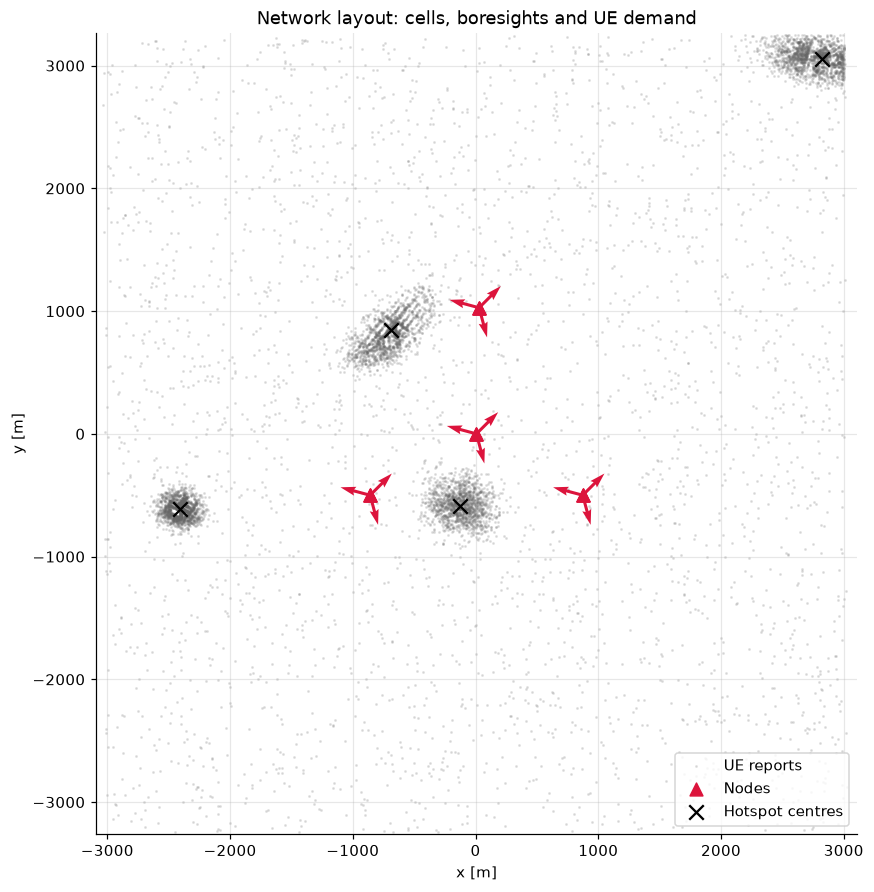

In [18]:
nodes = cell_table.drop_duplicates("cell")
arrow_m = 250.0
figure, axis = plt.subplots(figsize=(8.0, 8.0), constrained_layout=True)
axis.scatter(ue["x"], ue["y"], s=1, alpha=0.15, color="0.4", label="UE reports")
axis.scatter(nodes["x"], nodes["y"], marker="^", s=70, color="crimson", zorder=3, label="Nodes")
# azimuth_deg is counter-clockwise from the x axis (src.core.cell.Cell).
azimuth = np.deg2rad(nodes["azimuth_deg"].to_numpy(float))
axis.quiver(
    nodes["x"], nodes["y"], np.cos(azimuth) * arrow_m, np.sin(azimuth) * arrow_m,
    angles="xy", scale_units="xy", scale=1, color="crimson", width=0.004, zorder=3,
)
axis.scatter(hotspots["x"], hotspots["y"], marker="x", s=90, color="black", zorder=4, label="Hotspot centres")
axis.set(xlim=extent[:2], ylim=extent[2:], aspect="equal", xlabel="x [m]", ylabel="y [m]",
         title="Network layout: cells, boresights and UE demand")
axis.legend(loc="lower right", frameon=True)
save_fig(figure, "network_layout")
plt.show()

### 10.2 RSRP Map and Overlap Map

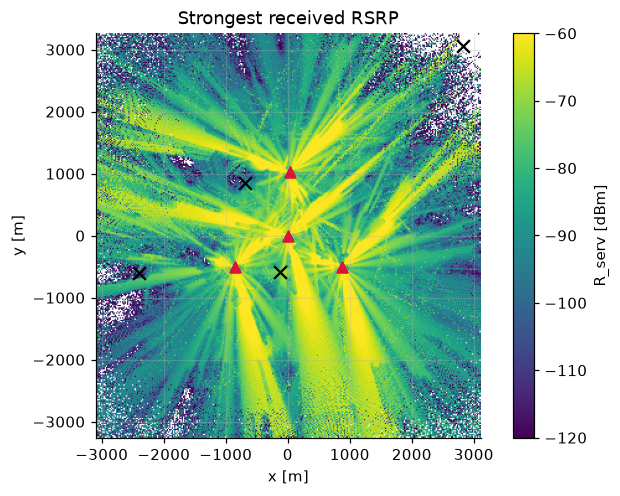

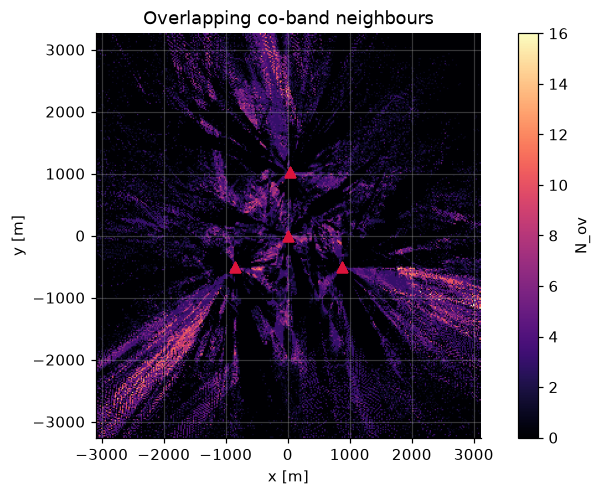

In [19]:
figure = plots.map_row(
    {"Strongest received RSRP": np.where(reached, r_serv, np.nan)},
    radio,
    colorbar_label="R_serv [dBm]",
    vmin=maps.RSRP_LIMITS[0],
    vmax=maps.RSRP_LIMITS[1],
    cells=nodes,
    hotspots=hotspots,
)
save_fig(figure, "rsrp_map")
plt.show()

figure = plots.map_row(
    {"Overlapping co-band neighbours": n_ov.astype(float)},
    radio,
    colorbar_label="N_ov",
    cmap="magma",
    cells=nodes,
)
save_fig(figure, "overlap_map")
plt.show()

### 10.3 Coverage Classification

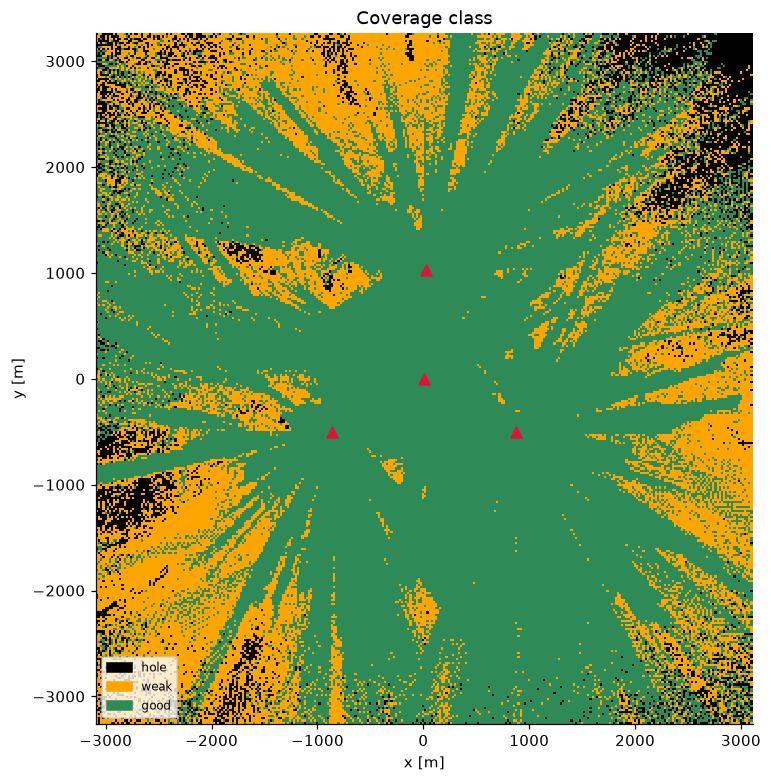

In [20]:
def class_map(axis, values, names, colours, title):
    '''Draw a categorical raster; ``values`` holds indices into ``names``, -1 for none.'''
    axis.imshow(np.where(values >= 0, values, np.nan), origin="lower", extent=extent,
                cmap=ListedColormap(colours), vmin=-0.5, vmax=len(names) - 0.5,
                interpolation="nearest")
    axis.scatter(nodes["x"], nodes["y"], marker="^", s=45, color="crimson", zorder=3)
    handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in colours]
    axis.legend(handles, names, loc="lower left", fontsize=8, frameon=True)
    axis.set(title=title, xlabel="x [m]", ylabel="y [m]")
    axis.grid(False)


figure, axis = plt.subplots(figsize=(7.0, 7.0), constrained_layout=True)
class_map(axis, coverage, [label(c) for c in maps.COVERAGE_CLASSES],
          ["black", "orange", "seagreen"], "Coverage class")
save_fig(figure, "coverage_map")
plt.show()

## 11. Preprocessing Pipeline

```text
simulation artifacts (npz, 2 csv, json)  +  configs/simulation.yaml, configs/kpi.yaml
        │
        ▼
load_artifacts            read-only
        │
        ▼
schema.verify / require   contract checks; stop on any violation
        │
        ├──────────────► read-only views: coverage, overlap,
        │                UE weighting, baseline KPIs  →  reports/
        ▼
build_ue / build_mdt /   typing, scenario_id, row order; no value changes
build_cells
        │
        ▼
save                      data/processed/ue.parquet, mdt.parquet, cell.parquet
        │
        ▼
optimization (task optim): search and score on ue.parquet
```

## 12. Output

| Output | Written by | Content |
| --- | --- | --- |
| `data/processed/ue.parquet` | `build_ue` | Every UE report, typed, with `scenario_id` |
| `data/processed/mdt.parquet` | `build_mdt` | The MDT reports, typed alike, with `rsrp_dbm` and `scenario_id` |
| `data/processed/cell.parquet` | `build_cells` | One row per (cell, band): geometry, frequency, baseline tilt and bounds, `max_prb` |
| `reports/tables/02_preprocessing/` | this notebook | Checks, coverage/overlap tables, UE-weighted indicators, baseline KPIs, quality summary |
| `reports/figures/02_preprocessing/` | this notebook | Layout, RSRP, overlap and coverage maps |

The radio map stays at `data/interim/radio_map.npz`. Every optimizer re-solves it per candidate, so there is no stored feature set or scaling parameter. TuRBO's unit-cube rescaling reads the tilt bounds from the config, not statistics of the data.

## 13. Key Takeaways

- **The artifacts meet their contract.** Every schema check and every template check holds. Nothing is dropped, imputed or rescaled, so the before and after columns of the quality summary agree. The UE table only gains `scenario_id` and compact dtypes.
- **Two UE datasets are written.** `ue.parquet` keeps all 10 066 UE rows, which the search and evaluation count; `mdt.parquet` keeps the 5 756 (57 %) served at the committed tilts, for later use. Every MDT row is a UE row, above the hole threshold and at most the RS power, and both round-trip through Parquet unchanged.
- **Missing RSRP is physical.** A large share of every band's layers has no propagation path, and the low band is reached more often than the two high bands. These NaNs enter the KPIs as $-\infty$, so they count as holes and are never read as zero signal.
- **Area and demand disagree.** Good coverage concentrates around the four nodes and along their boresights, while holes sit at the grid edges and in shadowed pockets. Hotspots can fall in those regions, so the UE-weighted hole share is higher than the tile-weighted one. The optimizer's hole and weak rates are tile-weighted by definition (`src/kpi/hole.py`, `src/kpi/weak.py`), and the UE-weighted view is a diagnostic beside them.
- **Overlap follows geometry.** Co-band neighbours pile up close to the nodes and along long line-of-sight corridors, where one band's cells see each other within the overlap margin.
- **The search starts from one tilt per band.** Every cell starts at 12° on 2600 MHz, 9° on 1800 MHz and 6° on 700 MHz, inside the 0–15° bounds and away from both ends, so the optimizer is free to uptilt or downtilt every dimension.